In [1]:
from downsample_raster import downsample_raster, process_folder
from rasterio.enums import Resampling
from pathlib import Path

In [11]:
input = Path(r"C:\FAO_commodities_presence_absence\raw_ee\rice_2023")
output = Path(r"C:\FAO_commodities_presence_absence\intermediate_process\downsample_rice_2023")
src_file = input / "rice_binary_IDN_2020.tif"
dst_file = output / "rice_binary_IDN_2020_downsampled.tif"

In [6]:
frac = downsample_raster(src_file, dst_file, factor = 10, resampling = Resampling.average, nodata = 0)
frac.shape, frac.dtype, frac.min(), frac.max()

((1, 6159, 17004), dtype('int16'), np.int16(0), np.int16(1))

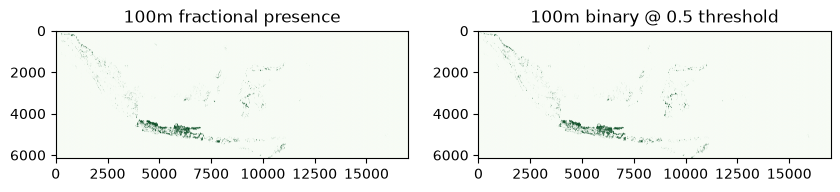

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(frac[0], cmap="Greens", vmin=0, vmax=1)
axes[0].set_title("100m fractional presence")

binary = (frac[0] >= 0.5).astype("uint8")
axes[1].imshow(binary, cmap="Greens")
axes[1].set_title("100m binary @ 0.5 threshold")
plt.show()

In [12]:
process_folder(
    in_folder=input,
    out_folder=output,
    factor=10,
    threshold=0.5,)

[rice_binary_BTN_2022.tif] downsampling 10x -> fractional cover ...
  -> rice_binary_BTN_2022.tif (fractional), rice_binary_BTN_2022_binary.tif (binary @ 0.5)
[rice_binary_IDN_2023.tif] downsampling 10x -> fractional cover ...
  -> rice_binary_IDN_2023.tif (fractional), rice_binary_IDN_2023_binary.tif (binary @ 0.5)
[rice_binary_KHM_2023.tif] downsampling 10x -> fractional cover ...
  -> rice_binary_KHM_2023.tif (fractional), rice_binary_KHM_2023_binary.tif (binary @ 0.5)
[rice_binary_LAO_2023.tif] downsampling 10x -> fractional cover ...
  -> rice_binary_LAO_2023.tif (fractional), rice_binary_LAO_2023_binary.tif (binary @ 0.5)
[rice_binary_MMR_2023.tif] downsampling 10x -> fractional cover ...
  -> rice_binary_MMR_2023.tif (fractional), rice_binary_MMR_2023_binary.tif (binary @ 0.5)
[rice_binary_MYS_2023.tif] downsampling 10x -> fractional cover ...
  -> rice_binary_MYS_2023.tif (fractional), rice_binary_MYS_2023_binary.tif (binary @ 0.5)
[rice_binary_PHL_2023.tif] downsampling 10x ->